## Comparing multifractal parameters of km-scale models and observations

In [1]:
import os
import autoroot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
multifractal_results_df = pd.read_csv(
    os.path.join(autoroot.root, "data/multifractals/multifractal_patch_comparison.csv")
)
multifractal_results_df.head()

,patch_number,lat,lon,goes_a,ifs_a,icon_a,goes_zeta_infinity,ifs_zeta_infinity,icon_zeta_infinity
0,94,18.248724,324.67220,0.441878,0.514254,0.377336,3.055879,4.560236,2.310644
1,95,16.479284,328.64972,0.468491,0.493910,0.383346,2.892180,5.085707,2.129660
2,96,14.725903,332.62717,0.483147,0.519878,0.412012,2.664841,3.967110,2.272448
3,120,18.248724,316.71722,0.445713,0.621009,0.324722,3.029163,4.198385,2.157876
4,121,16.479284,320.69476,0.428807,0.539417,0.361393,3.150153,4.178442,2.101624


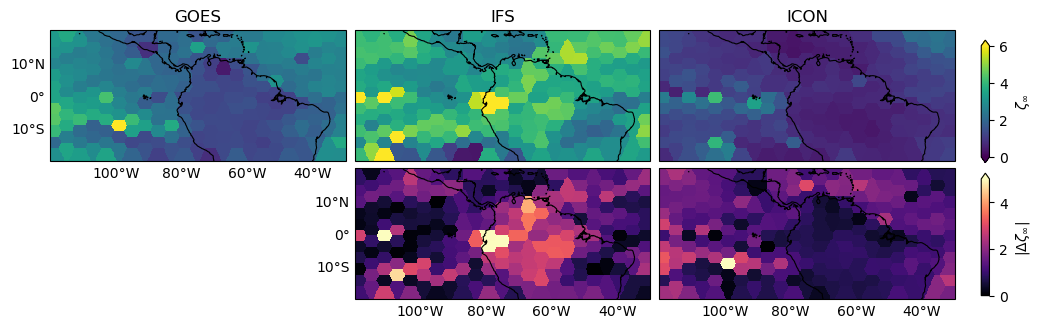

In [4]:
fig, axs = plt.subplots(2, 3, figsize=(11.75, 3.5), subplot_kw={'projection': ccrs.PlateCarree()})

# define grid boundaries and resolution
lon_min, lon_max, lat_min, lat_max = 360-120, 360-30, -20, 20
res = 0.25

grid_lon = np.arange(lon_min, lon_max + res, res)
grid_lat = np.arange(lat_min, lat_max + res, res)
lon_grid, lat_grid = np.meshgrid(grid_lon, grid_lat)

points = multifractal_results_df[['lon', 'lat']].values

# plot zeta_infinity maps in first row
gridded_maps = {}

for i, dataset in enumerate(['goes', 'ifs', 'icon']):
    zI_values = multifractal_results_df[f'{dataset}_zeta_infinity'].values


    grid_zI = griddata(points, zI_values, (lon_grid, lat_grid), method='nearest')
    gridded_maps[dataset] = grid_zI
    ax = axs[0, i]

    # add features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    if i == 0:
        ax.set_yticks([-10, 0, 10], crs=ccrs.PlateCarree())
        ax.set_yticklabels(['10°S', '0°', '10°N'])
        ax.tick_params(axis='y', length=0)

        ax.set_xticks([-100, -80, -60, -40], crs=ccrs.PlateCarree())
        ax.set_xticklabels(['100°W', '80°W', '60°W', '40°W', ])
        ax.tick_params(axis='x', length=0) 

    c = ax.pcolormesh(lon_grid, lat_grid, grid_zI, cmap="viridis", shading='auto', vmin=0, vmax=6)
    ax.set_title(f"{dataset.upper()}")

fig.subplots_adjust(wspace=0.01, hspace=0.05)

cbar_ax = fig.add_axes([0.92, 0.5, 0.007, 0.35])  # tweak as needed
cbar=fig.colorbar(c, cax=cbar_ax, label=r"$\zeta_\infty$", extend='both')

# plot difference maps in second row
for i, dataset in enumerate(['goes', 'ifs', 'icon']):
    if dataset == 'goes':
        # remove subplot
        axs[1, i].axis('off')
        continue

    ## get difference in multifractal parameters between goes and ifs/icon
    zeta_diff = gridded_maps[dataset] - gridded_maps['goes']


    ax = axs[1, i]
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    

    if i == 1:
        ax.set_yticks([-10, 0, 10], crs=ccrs.PlateCarree())
        ax.set_yticklabels(['10°S', '0°', '10°N'])
        ax.tick_params(axis='y', length=0)

    ax.set_xticks([-100, -80, -60, -40], crs=ccrs.PlateCarree())
    ax.set_xticklabels(['100°W', '80°W', '60°W', '40°W', ])
    ax.tick_params(axis='x', length=0) 

    c = ax.pcolormesh(lon_grid, lat_grid, np.abs(zeta_diff), cmap="magma", shading='auto', vmin=0, vmax=5)

fig.subplots_adjust(wspace=0.01, hspace=0.05)

cbar_ax = fig.add_axes([0.92, 0.12, 0.007, 0.35])  # tweak as needed
fig.colorbar(c, cax=cbar_ax, label=r"$|\Delta \zeta_\infty|$", extend='max')